#### Import

In [1]:
import numpy as np; import pandas as pd; import matplotlib.pyplot as mp; import seaborn as sea; import datetime as dt; import random as r; import math as m; import statistics as st; import mysql.connector as ms; import warnings; warnings.filterwarnings("ignore"); warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy connectable*"); warnings.filterwarnings("ignore", message=".*is_categorical_dtype is deprecated.*"); warnings.filterwarnings("ignore", message="invalid escape sequence.*", category=SyntaxWarning)


#### Data

In [2]:
dbd="Layoffs"


#### Display

In [3]:
# from PIL import Image
# import matplotlib.pyplot as mp

# image_1 = Image.open(r"Image\Image 1.png")
# image_2 = Image.open(r"Image\Image 2.png")
# # image_3 = Image.open(r"Image\Image 3.png")

# images = [image_1, image_2]
# cols = 2
# rows = 2
# mp.figure(figsize=(10, 7),dpi=200)
# mp.subplots_adjust(wspace=0.1, hspace=0)

# for i, img in enumerate(images):
#     ax = mp.subplot(rows, cols, i + 1)
#     rotated = img.rotate(0)
#     ax.imshow(rotated, interpolation="nearest")
#     ax.set_xticks([])
#     ax.set_yticks([])
#     for spine in ax.spines.values():
#         spine.set_visible(True)
#         spine.set_color("black")
#         spine.set_linewidth(2)
#     ax.set_title(f"Page {i+1}",color="red")
# mp.show()

#### Views

In [4]:
db = ms.connect(
    host="localhost",
    user="root",
    password="67777777",
    database=dbd)
cur = db.cursor()
cur.execute("SHOW TABLES")
tables = [t[0] for t in cur.fetchall()]
for table in tables:
    print(f"\n===== {table} =====\n")
    df = pd.read_sql(f"SELECT * FROM {table}", con=db)
    print(" ,\n".join(df.columns))


===== layoffs =====

company ,
location ,
total_laid_off ,
date ,
percentage_laid_off ,
industry ,
source ,
stage ,
funds_raised ,
country ,
date_added ,
location_isnull ,
total_laid_off_isnull ,
percentage_laid_off_isnull ,
industry_isnull ,
source_isnull ,
stage_isnull ,
funds_raised_isnull ,
country_isnull

===== layoffss =====

com ,
loc ,
tlo ,
dat ,
plo ,
ind ,
sou ,
sta ,
fra ,
cou ,
dad ,
loc_in ,
tlo_in ,
plo_in ,
ind_in ,
sou_in ,
sta_in ,
fra_in ,
cou_in


In [5]:
query=""" 
create or replace view layoffss
as
select company as com,
location as loc,
total_laid_off as tlo,
date as dat,
percentage_laid_off as plo ,
industry as ind,
source as sou,
stage as sta,
funds_raised as fra,
country as cou,
date_added as dad,
location_isnull as loc_in,
total_laid_off_isnull as tlo_in,
percentage_laid_off_isnull as plo_in,
industry_isnull as ind_in,
source_isnull as sou_in,
stage_isnull as sta_in,
funds_raised_isnull as fra_in,
country_isnull as cou_in
from layoffs
"""
cur.execute(query)
data=cur.fetchall()


#### Columns

In [6]:
db = ms.connect(host = "localhost", 
                username = "root", 
                password = "67777777", 
                database = dbd) 
cur = db.cursor()
cur.execute("SHOW TABLES");tables=[t[0] for t in cur.fetchall()];dfs=[];import pandas as pd
for i,table in enumerate(tables,1):
 df=pd.read_sql(f"SELECT * FROM {table}",con=db)
 for col in df.columns:
  if 'date'in col.lower()or'time'in col.lower():df[col]=pd.to_datetime(df[col],errors='coerce')
 temp=pd.DataFrame({'Table':table,'Column':df.columns,'Type':[str(df[c].dtype)for c in df.columns]});temp.index=[i]*len(temp);temp.index.name='index';dfs+=[temp,pd.DataFrame([['','','']],columns=temp.columns,index=[""])]
cn_final=pd.concat(dfs);print(f"\n{'':<8}{'Table':<20}{'Column':30}{'Type'}\n")
for i,table in enumerate(tables,1):
 for _,r in cn_final[cn_final['Table']==table].iterrows():print(f"{i:<5}{r['Table']:<18}{r['Column']:<35}{r['Type']}")
 print()
print("All tables in the database:\n"); 
for table in tables: print(f"{table}")


        Table               Column                        Type

1    layoffs           company                            str
1    layoffs           location                           str
1    layoffs           total_laid_off                     float64
1    layoffs           date                               datetime64[us]
1    layoffs           percentage_laid_off                float64
1    layoffs           industry                           str
1    layoffs           source                             str
1    layoffs           stage                              str
1    layoffs           funds_raised                       float64
1    layoffs           country                            str
1    layoffs           date_added                         datetime64[us]
1    layoffs           location_isnull                    int64
1    layoffs           total_laid_off_isnull              int64
1    layoffs           percentage_laid_off_isnull         int64
1    layoffs           indu

#### Table

In [7]:
table="layoffs"
try:display(pd.read_sql(f"select * from {table}", db).pipe(lambda df: df.rename(columns=lambda c: f"{c} (c{df.columns.get_loc(c)+1})").head(3).style.hide(axis="index").set_properties(**{'text-align':'left'}).set_table_styles([{'selector':'th','props':[('text-align','center'),('border','1.5px solid white')]},{'selector':'td','props':[('border','1px solid white')]}])))
except:pass

company (c1),location (c2),total_laid_off (c3),date (c4),percentage_laid_off (c5),industry (c6),source (c7),stage (c8),funds_raised (c9),country (c10),date_added (c11),location_isnull (c12),total_laid_off_isnull (c13),percentage_laid_off_isnull (c14),industry_isnull (c15),source_isnull (c16),stage_isnull (c17),funds_raised_isnull (c18),country_isnull (c19)
ClickUp,San Diego,nan,2026-05-21 00:00:00,0.220000,Other,https://x.com/DJ_CURFEW/status/2057522382315929802?s=20,Series C,537.000000,United States,2026-05-21 00:00:00,1,0,1,1,1,1,1,1
Intuit,SF Bay Area,3000.000000,2026-05-20 00:00:00,0.170000,Finance,https://www.reuters.com/business/world-at-work/intuit-cut-17-global-jobs-streamline-operations-memo-shows-2026-05-20/,Post-IPO,18.000000,United States,2026-05-20 00:00:00,1,1,1,1,1,1,1,1
AI21 Labs,Tel Aviv,110.000000,2026-05-18 00:00:00,0.610000,AI,https://en.globes.co.il/en/article-shashuas-ai21-labs-laying-off-60-of-employees-1001543241,Series D,626.000000,Israel,2026-05-20 00:00:00,1,1,1,1,1,1,1,1


#### Tables All

In [8]:
from IPython.display import display
import pandas as pd
cur.execute("SHOW TABLES")
tables = [t[0] for t in cur.fetchall()]
for i, table in enumerate(tables, start=1):
    print(f"\n{'='*60}")
    print(f"Table {i}: {table}")
    print(f"{'='*60}")
    df = pd.read_sql(f"SELECT * FROM {table} LIMIT 5", con=db)
    df = df.rename(columns={col: f"{col} (c{i+1})" for i, col in enumerate(df.columns)})
    display(df.head(2).style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
    


Table 1: layoffs


company (c1),location (c2),total_laid_off (c3),date (c4),percentage_laid_off (c5),industry (c6),source (c7),stage (c8),funds_raised (c9),country (c10),date_added (c11),location_isnull (c12),total_laid_off_isnull (c13),percentage_laid_off_isnull (c14),industry_isnull (c15),source_isnull (c16),stage_isnull (c17),funds_raised_isnull (c18),country_isnull (c19)
ClickUp,San Diego,nan,2026-05-21 00:00:00,0.220000,Other,https://x.com/DJ_CURFEW/status/2057522382315929802?s=20,Series C,537.000000,United States,2026-05-21 00:00:00,1,0,1,1,1,1,1,1
Intuit,SF Bay Area,3000.000000,2026-05-20 00:00:00,0.170000,Finance,https://www.reuters.com/business/world-at-work/intuit-cut-17-global-jobs-streamline-operations-memo-shows-2026-05-20/,Post-IPO,18.000000,United States,2026-05-20 00:00:00,1,1,1,1,1,1,1,1



Table 2: layoffss


com (c1),loc (c2),tlo (c3),dat (c4),plo (c5),ind (c6),sou (c7),sta (c8),fra (c9),cou (c10),dad (c11),loc_in (c12),tlo_in (c13),plo_in (c14),ind_in (c15),sou_in (c16),sta_in (c17),fra_in (c18),cou_in (c19)
ClickUp,San Diego,nan,2026-05-21 00:00:00,0.220000,Other,https://x.com/DJ_CURFEW/status/2057522382315929802?s=20,Series C,537.000000,United States,2026-05-21 00:00:00,1,0,1,1,1,1,1,1
Intuit,SF Bay Area,3000.000000,2026-05-20 00:00:00,0.170000,Finance,https://www.reuters.com/business/world-at-work/intuit-cut-17-global-jobs-streamline-operations-memo-shows-2026-05-20/,Post-IPO,18.000000,United States,2026-05-20 00:00:00,1,1,1,1,1,1,1,1


#### 1. Find the top 5 companies with the highest total layoffs.

company,total_layoffs
Amazon,58124.000000
Intel,43115.000000
Meta,35700.000000
Oracle,31294.000000
Microsoft,30055.000000


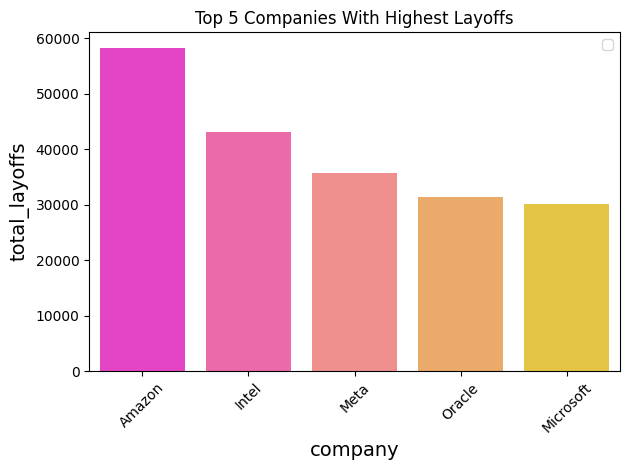

In [9]:
query=""" 
with a as (
select com,sum(tlo) as total_layoffs ,
dense_rank() over(order by sum(tlo) desc) as drank
from layoffss
group by com
)
select com as company, total_layoffs
from a
where drank<=5
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
sea.barplot(data=df,x="company",y="total_layoffs",palette="spring",errorbar=("ci",0))
mp.xlabel("company",fontsize=14,rotation=0)
mp.ylabel("total_layoffs",fontsize=14,rotation=90)
mp.title("Top 5 Companies With Highest Layoffs")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()

#### 2. Find the number of layoffs by each industry.

industry,number_of_layoffs
Other,119746.000000
Retail,106306.000000
Hardware,106157.000000
Consumer,96712.000000
Finance,67565.000000


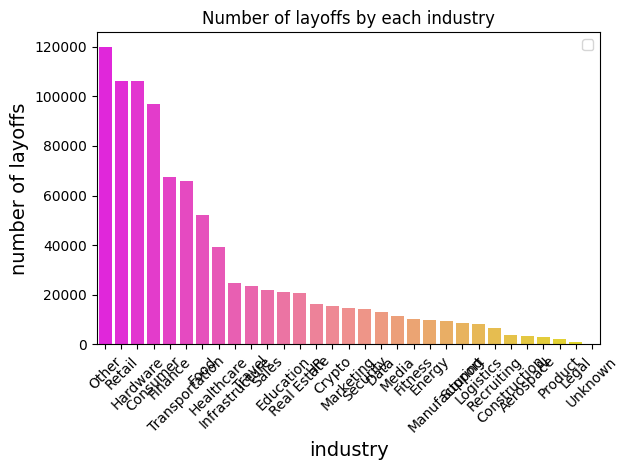

In [10]:
query=""" 
select ind as industry,sum(tlo) as number_of_layoffs
from layoffss
group by ind
order by sum(tlo) desc
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
a=True
b=False
df = df.sort_values(by=["number_of_layoffs"], ascending=[b])
df = df.reset_index(drop=True)
sea.barplot(data=df,x="industry",y="number_of_layoffs",palette="spring",errorbar=("ci",0))
mp.xlabel("industry",fontsize=14,rotation=0)
mp.ylabel("number of layoffs",fontsize=14,rotation=90)
mp.title("Number of layoffs by each industry")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()

#### 3. Find the average percentage_laid_off for each country.

country,average_percentage_laid_off
Unknown,1.000000
Vietnam,0.833333
Nigeria,0.582857
UAE,0.550000
Pakistan,0.542000


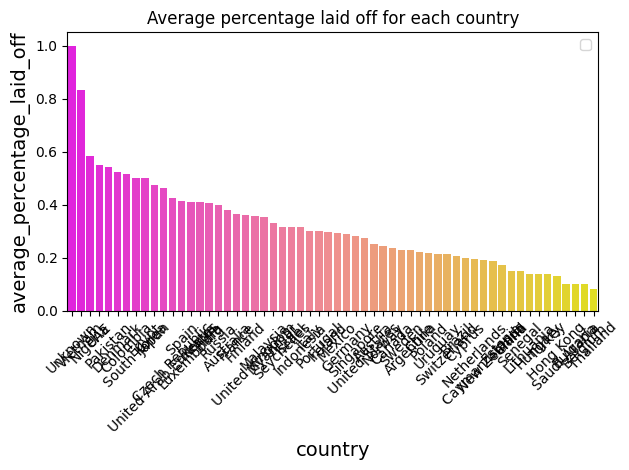

In [11]:
query=""" 
select cou as country,avg(plo) as average_percentage_laid_off
from layoffss
where plo_in=1
group by cou
order by 2 desc
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
sea.barplot(data=df,x="country",y="average_percentage_laid_off",palette="spring",errorbar=("ci",0))
mp.xlabel("country",fontsize=14,rotation=0)
mp.ylabel("average_percentage_laid_off",fontsize=14,rotation=90)
mp.title("Average percentage laid off for each country")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()

#### 4. Find the month-wise total layoffs trend.

year_months,month,year,total_layoffs
202003,3,2020,9628.000000
202004,4,2020,26710.000000
202005,5,2020,25804.000000
202006,6,2020,7627.000000
202007,7,2020,7112.000000


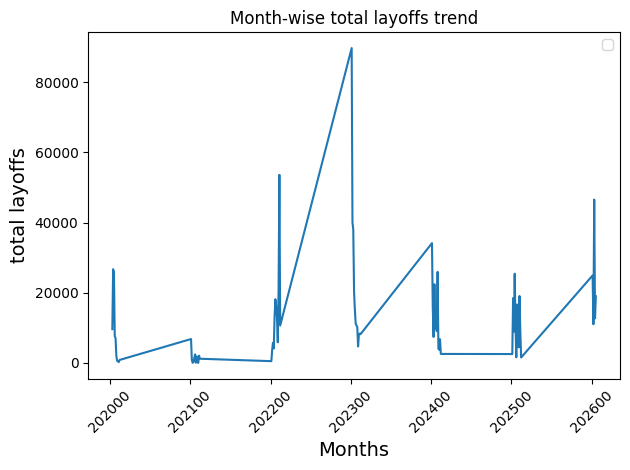

In [12]:
query=""" 
select extract(year_month from dat) as year_months,extract(month from dat) as month,extract(year from dat) as year,sum(tlo) as total_layoffs 
from layoffss
group by 1,2,3
order by 1
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
sea.lineplot(data=df,x="year_months",y="total_layoffs")
mp.xlabel("Months",fontsize=14,rotation=0)
mp.ylabel("total layoffs",fontsize=14,rotation=90)
mp.title("Month-wise total layoffs trend")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()


#### 5. Find the companies that laid off 100% employees.

company,laid_off,total_layoffs
Katerra,1.000000,2434.000000
Butler Hospitality,1.000000,1000.000000
Lilium,1.000000,1000.000000
Redbox,1.000000,1000.000000
Bitwise,1.000000,900.000000


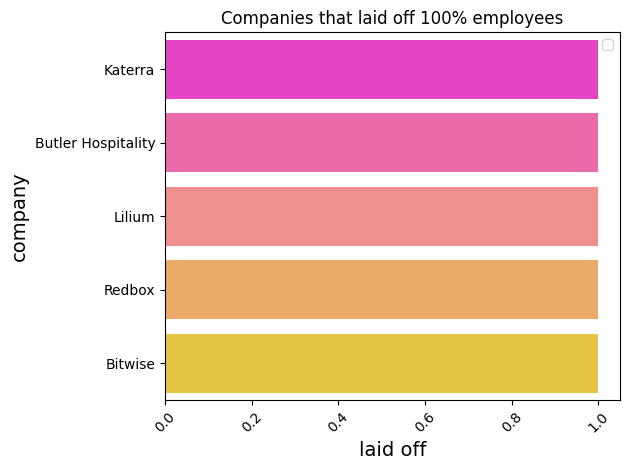

In [13]:
query=""" 
select distinct com as company,plo as laid_off,tlo as total_layoffs
from layoffss
where plo=1
order by total_layoffs desc
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
a=True
b=False
df = df.sort_values(by=["total_layoffs","company"], ascending=[b,a])
df = df.reset_index(drop=True)
df = df.head()
sea.barplot(data=df,x="laid_off",y="company",palette="spring",errorbar=("ci",0))
mp.xlabel("laid off",fontsize=14,rotation=0)
mp.ylabel("company",fontsize=14,rotation=90)
mp.title("Companies that laid off 100% employees")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()


#### 6. Find the top industry in each country with the highest layoffs.

country,industry,layoffs
United States,Hardware,101567.000000
India,Education,14474.000000
Germany,Other,12207.000000
United Kingdom,Food,10404.000000
Sweden,Other,10250.000000


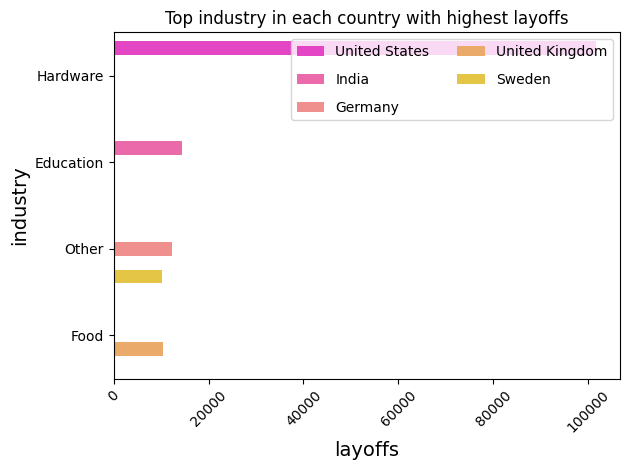

In [14]:
query=""" 
with a as (
select cou,ind,sum(tlo) as tlo,
dense_rank() over(partition by cou order by sum(tlo) desc) as drank
from layoffss
where tlo_in=1
group by cou,ind
)
select cou as country,ind as industry,tlo as layoffs
from a
where drank=1
order by layoffs desc
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
a=True
b=False
df = df.sort_values(by=["layoffs"], ascending=[b])
df = df.reset_index(drop=True)
df=df.head()
sea.barplot(data=df,x="layoffs",y="industry",hue="country",palette="spring",errorbar=("ci",0))
mp.xlabel("layoffs",fontsize=14,rotation=0)
mp.ylabel("industry",fontsize=14,rotation=90)
mp.title("Top industry in each country with highest layoffs")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()


#### 7. Find the cumulative total layoffs over time for each country.

country,time,layoffs
Germany,202004,166.000000
Germany,202005,166.000000
Germany,202006,366.000000
Germany,202007,441.000000
Germany,202008,441.000000


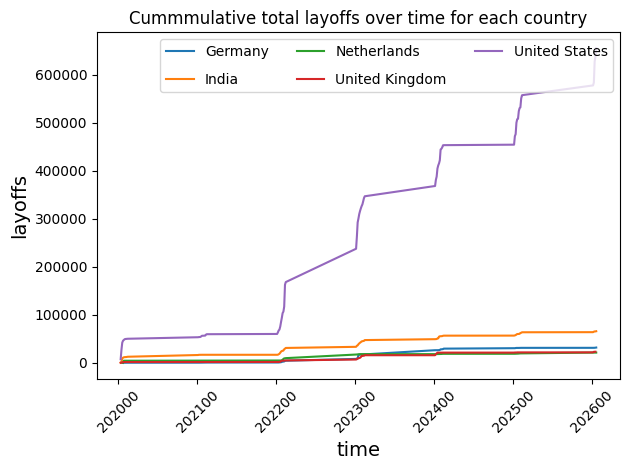

In [15]:
query=""" 
with a as (
select cou,extract(year_month from dat) df,sum(tlo) as tt
from layoffss
group by 1,2
),b as (
select cou,df,
sum(tt) over(partition by cou order by df asc) as layoffs
from a
),top5 as (
select cou,max(layoffs) as tl
from b
group by cou
order by tl desc
limit 5
)
select b.cou as country,b.df as time,b.layoffs as layoffs
from b 
join top5 
on b.cou=top5.cou
order by country
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
sea.lineplot(data=df,x="time",y="layoffs",hue="country")
mp.xlabel("time",fontsize=14,rotation=0)
mp.ylabel("layoffs",fontsize=14,rotation=90)
mp.title("Cummmulative total layoffs over time for each country")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=3,labelspacing=1)
mp.tight_layout()
mp.show()


#### 8. Find the companies whose total_laid_off is above the industry average.

industry,company,layoffs
Aerospace,Blue Origin,1040.000000
Aerospace,Lilium,1000.000000
Aerospace,OneWeb,451.000000
AI,C3.ai,280.000000
AI,Krutrim,150.000000


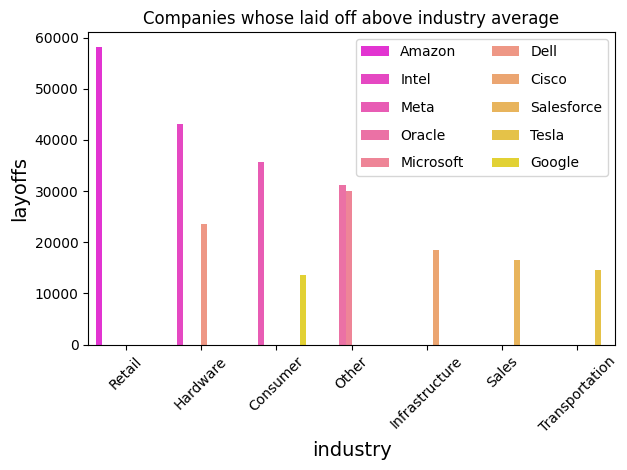

In [16]:
query=""" 
with a as (
select ind,com,sum(tlo) as tlo 
from layoffss
group by ind,com
),b as (
select ind,avg(tlo) as tlo
from a
group by ind
)
select a.ind as industry,a.com as company,a.tlo as layoffs
from a 
join b b on a.ind=b.ind
where a.tlo>b.tlo
order by 1
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
a=True
b=False
df = df.sort_values(by=["layoffs"], ascending=[b])
df = df.reset_index(drop=True)
df=df.head(10)
sea.barplot(data=df,x="industry",y="layoffs",hue="company",palette="spring",errorbar=("ci",0))
mp.xlabel("industry",fontsize=14,rotation=0)
mp.ylabel("layoffs",fontsize=14,rotation=90)
mp.title("Companies whose laid off above industry average")
mp.xticks(rotation=45)
mp.yticks(rotation=0)
mp.legend(loc=1,bbox_to_anchor=(1,1,0,0),ncols=2,labelspacing=1)
mp.tight_layout()
mp.show()


#### 9. Find the stage-wise percentage contribution to total layoffs.

stage,percentage_contribution
Acquired,8.742944
Post-IPO,69.410331
Private Equity,1.562733
Seed,0.302391
Series A,1.092838


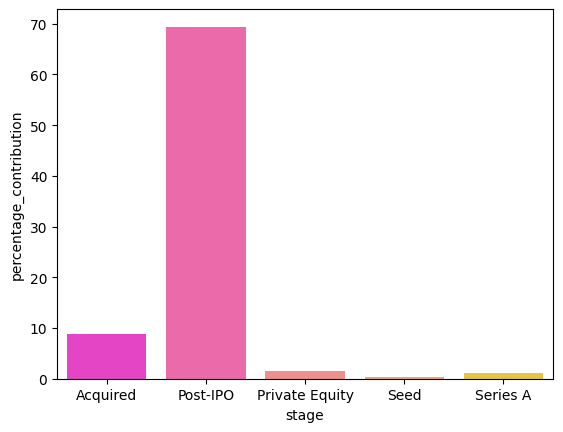

In [17]:
query=""" 
with a as (
select sta,tlo,
sum(tlo) over() as drank 
from layoffss
where sta_in=1
)
select sta as stage,100.0*sum(tlo)/max(drank) as percentage_contribution
from a
group by sta
order by sta
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
df=df.head()
sea.barplot(data=df,x="stage",y="percentage_contribution",palette="spring",errorbar=("ci",0))
mp.show()


#### 10. Find the company with the highest layoffs in each year and country combination.

year,country,company,layoffs
2020,Australia,Deputy,60.000000
2020,Brazil,Stone,1300.000000
2020,Bulgaria,ScaleFocus,120.000000
2020,Canada,Ritual,196.000000
2020,Denmark,Labster,40.000000


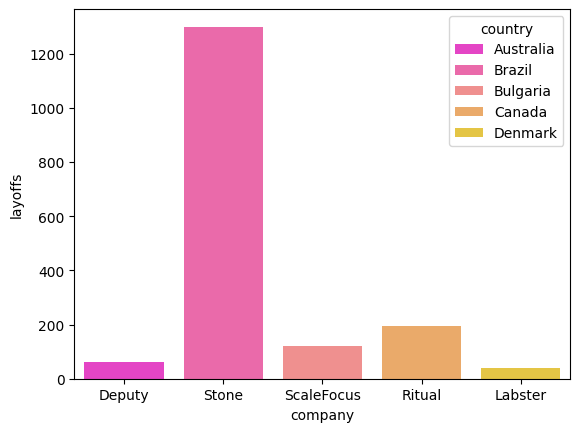

In [18]:
query=""" 
with a as (
select extract(year from dat) as year,com as company,cou as country,tlo as layoffs,
row_number() over(partition by extract(year from dat),cou order by tlo desc) as drank
from layoffss
where tlo_in=1
order by year,cou)
select year,country,company,layoffs
from a
where drank=1
"""
cur.execute(query)
data=cur.fetchall()
columns = [col[0] for col in cur.description]
df = pd.DataFrame(data, columns=columns)
display(df.head().style.hide(axis="index").set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]},{'selector': 'th', 'props': [('border', '1.5px solid white')]},{'selector': 'td', 'props': [('border', '1px solid white')]}]))
df=df.head()
sea.barplot(data=df,x="company",y="layoffs",hue="country",palette="spring",errorbar=("ci",0))
mp.show()